# 3.2 - Baseline Models: Linear Regression & Regularization

**Taller de Programación - UBA FCE | Grupo JLP**

---

## Objetivo

Establecer modelos baseline simples para predecir precios de commodities agrícolas:

1. **Linear Regression (OLS):** Modelo más simple, interpretable
2. **Ridge Regression (L2):** Regularización para evitar overfitting
3. **Lasso Regression (L1):** Regularización + selección automática de features
4. **Elastic Net:** Combinación L1 + L2

**Métricas de evaluación:**
- **RMSE** (Root Mean Squared Error): Error en mismas unidades que target
- **MAE** (Mean Absolute Error): Menos sensible a outliers
- **R²**: Porcentaje de varianza explicada
- **Directional Accuracy**: ¿Predecimos correctamente si sube/baja?

## Setup

In [ ]:
# Imports
import pandas as pd
import numpy as np
from pathlib import Path
import sys
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, cross_val_score, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tqdm.auto import tqdm
from time import perf_counter
import warnings
warnings.filterwarnings('ignore')

# Agregar src al path
BASE_DIR = Path.cwd().parents[1]
sys.path.append(str(BASE_DIR / 'src'))

from config import PROCESSED_DIR, logger
from utils.cuda_config import get_cuda_config

# Configurar pandas display
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 1000)

# Configurar GPU/CUDA
cuda_config = get_cuda_config(verbose=True)

# Configurar CuPy para aceleración GPU en scaling
from utils.cupy_config import get_cupy_config, CUPY_AVAILABLE, get_array_module
cupy_config = get_cupy_config(verbose=True)

# Definir commodities target
TARGET_COMMODITIES = ['Corn', 'Soybeans', 'Wheat']

print(f"\n✓ Base directory: {BASE_DIR}")
print(f"✓ Target commodities: {', '.join(TARGET_COMMODITIES)}")


CONFIGURACIÓN DE DISPOSITIVO GPU/CPU
✓ GPU DETECTADA
  - Dispositivo: NVIDIA GeForce RTX 3060
  - Tipo: CUDA
  - Memoria: 12.9 GB

✓ FRAMEWORKS COMPATIBLES:
  - Pytorch: Sí
  - Xgboost: Sí
  - Lightgbm: Sí

CONFIGURACIÓN CuPy - GPU ACCELERATION

1. Sistema operativo: win32
2. Python executable: f:\miniconda\envs\ds\python.exe

3. Configurando CUDA DLL paths (Windows)...
   ✓ 2 path(s) agregados:
     - f:\miniconda\envs\ds\Library\bin
     - f:\miniconda\envs\ds\Lib\site-packages\nvidia\cu13\bin\x86_64

4. Importando CuPy...
   ✓ CuPy importado exitosamente

5. Verificando acceso a GPU...

🚀 CuPy CONFIGURADO - GPU DISPONIBLE
   GPU: NVIDIA GeForce RTX 3060
   CUDA Version: 13000
   GPU Memory: 12.00 GB total
   Free Memory: 10.98 GB
   ✓ Test de operación GPU exitoso


✓ Base directory: c:\Users\trico\OneDrive\UBA\Taller de Programacion\TPFinal
✓ Target commodities: Corn, Soybeans, Wheat
CONFIGURACIÓN CuPy - GPU ACCELERATION

1. Sistema operativo: win32
2. Python executable: f:\minicon

## 1. Cargar Features Seleccionadas

In [ ]:
# Cargar dataset limpio con features seleccionadas
input_file = PROCESSED_DIR / 'features_selected_modeling.csv'

if not input_file.exists():
    raise FileNotFoundError(
        f"No se encontró {input_file}.\n"
        "Ejecuta notebook 3.1-feature-selection.ipynb primero."
    )

df = pd.read_csv(input_file, parse_dates=['date'])

print(f"✓ Dataset cargado: {input_file.name}")
print(f"  Dimensiones: {df.shape}")
print(f"  Período: {df['date'].min().date()} → {df['date'].max().date()}")
print(f"  Missing values: {df.isnull().sum().sum()} (debe ser 0)")

# Verificar que está limpio
assert df.isnull().sum().sum() == 0, "ERROR: Dataset tiene NaNs"

# Separar features y targets
target_cols = [f'{c}_target_t7' for c in TARGET_COMMODITIES]
feature_cols = [c for c in df.columns if c not in ['date'] + target_cols]

print(f"\nDataset structure:")
print(f"  Features: {len(feature_cols)}")
print(f"  Targets: {len(target_cols)}")

display(df.head())


✓ Dataset cargado: features_selected_modeling.csv
  Dimensiones: (6724, 48)
  Período: 2000-01-03 → 2025-10-30
  Missing values: 0 (debe ser 0)

Dataset structure:
  Features: 44
  Targets: 3


,date,Soybean_Meal_vol_ratio_30_90,Heating_Oil_volume_std90,Heating_Oil_volume_bb_upper90,Wheat_ma90,Corn_price_to_ma7,Coffee_volume_ma90,Oat_volume_bb_lower90,Wheat_bb_upper7,Corn_ma90,Corn_price_to_ma30,Wheat_bb_upper30,Feeder_Cattle_volume_std90,Soybean_Oil_bb_lower30,Brent_Crude_volume_bb_lower90,Corn_volume_std90,Sugar_volume_bb_lower7,Soybean_Oil_bb_upper30,Copper_bb_upper90,Coffee_volume_bb_lower30,Temp_Global_Grain_bb_lower30,Precip_Deficit_vol_ratio_30_90,Soybean_Oil_ma30,Copper_bb_upper30,WindSpeed_Global_Grain_bb_upper30,Copper_ma90,Soybeans_log_return90,Wheat_Kansas_ma90,ONI_bb_lower30,Soybeans_ma7,Wheat_price_to_ma90,Soybean_Meal_bb_lower90,Cocoa_ma90,Corn_volume_ma30,Silver_lag7,Oat_ma90,USD_BRL_std90,Corn_ma7,Copper_ma30,Wheat_lag3,Platinum_std90,USD_BRL_price_to_ma90,Soybean_Meal_volume_ma90,Cotton_volume_bb_lower7,Corn_volume_log_return7,Corn_target_t7,Soybeans_target_t7,Wheat_target_t7
0,2000-01-03,0.586399,14934.858456,73035.618462,518.962644,1.000567,6640.00,-199.385793,540.326089,376.264706,1.002732,555.477155,1200.369604,31.658976,3818.339863,63489.705862,17475.974554,35.502189,3.287891,-6453.202012,14.518226,0.529354,33.537241,3.188825,2.093688,3.034517,0.009985,515.889205,-0.33223,987.166667,0.997932,281.838609,830.000000,95597.0,16.952999,116.750000,0.086541,377.928571,3.041333,519.5,43.659780,0.999356,21104.068966,-3.826984,-0.032046,377.75,986.75,519.5
1,2000-01-04,0.586399,14934.858456,73035.618462,518.962644,1.000567,6066.00,-7.142136,540.326089,376.264706,1.002732,555.477155,1200.369604,31.658976,3818.339863,63489.705862,17475.974554,35.502189,3.287891,4442.482830,11.131809,1.000000,33.537241,3.188825,1.836405,3.034517,0.009985,515.889205,-1.66000,987.166667,0.997932,281.838609,833.000000,95597.0,16.952999,116.875000,0.086541,377.928571,3.041333,519.5,43.659780,0.999356,21104.068966,1670.154119,-0.032046,377.75,986.75,519.5
2,2000-01-05,0.586399,14934.858456,73035.618462,518.962644,1.000567,6099.00,-3.399779,540.326089,376.264706,1.002732,555.477155,1200.369604,31.658976,3818.339863,63489.705862,17475.974554,35.502189,3.287891,4945.322402,11.999513,1.000000,33.537241,3.188825,1.992413,3.034517,0.009985,515.889205,-1.66000,987.166667,0.997932,281.838609,832.333333,95597.0,16.952999,116.833333,0.086541,377.928571,3.041333,519.5,6.929659,0.999356,21104.068966,1957.285105,-0.032046,377.75,986.75,519.5
3,2000-01-06,0.586399,14934.858456,73035.618462,518.962644,1.000567,5847.75,-1.746211,540.326089,376.264706,1.002732,555.477155,1200.369604,31.658976,3818.339863,63489.705862,17475.974554,35.502189,3.287891,4470.310467,12.316597,1.000000,33.537241,3.188825,2.106413,3.034517,0.009985,515.889205,-1.66000,987.166667,0.997932,281.838609,834.500000,95597.0,16.952999,116.875000,0.086541,377.928571,3.041333,519.5,8.866986,0.999356,21104.068966,2870.287107,-0.032046,377.75,986.75,519.5
4,2000-01-07,0.586399,14934.858456,73035.618462,518.962644,1.000567,6049.20,-0.755418,540.326089,376.264706,1.002732,555.477155,1200.369604,31.658976,3818.339863,63489.705862,17475.974554,35.502189,3.287891,4554.326494,12.615581,1.000000,33.537241,3.188825,2.051555,3.034517,0.009985,515.889205,-1.66000,987.166667,0.997932,281.838609,838.200000,95597.0,16.952999,116.950000,0.086541,377.928571,3.041333,519.5,7.942717,0.999356,21104.068966,-1336.749411,-0.032046,377.75,986.75,519.5


## 2. Train/Test Split Temporal

**CRÍTICO:** NO usar shuffle en series temporales → data leakage.

Usamos split temporal:
- **Train:** 2000-2022 (~80%)
- **Test:** 2023-2025 (~20%)

In [ ]:
# Split temporal
split_date = '2023-01-01'
train_idx = df['date'] < split_date
test_idx = df['date'] >= split_date

X_train = df.loc[train_idx, feature_cols]
X_test = df.loc[test_idx, feature_cols]
y_train = df.loc[train_idx, target_cols]
y_test = df.loc[test_idx, target_cols]

print(f"Train/Test split temporal:")
print(f"  Train: {X_train.shape[0]:,} obs (hasta {split_date})")
print(f"  Test: {X_test.shape[0]:,} obs (desde {split_date})")
print(f"  Proporción: {X_train.shape[0] / df.shape[0]:.1%} / {X_test.shape[0] / df.shape[0]:.1%}")

# CRÍTICO: Limpiar NaN en targets (filas sin target válido)
print(f"\nVerificando NaN en targets...")
nan_train = y_train.isnull().sum().sum()
nan_test = y_test.isnull().sum().sum()
print(f"  NaN en y_train: {nan_train} | NaN en y_test: {nan_test}")

if nan_train > 0 or nan_test > 0:
    print(f"  Eliminando filas con NaN en targets...")
    # Identificar filas válidas (todas las columnas target sin NaN)
    valid_train = y_train.notna().all(axis=1)
    valid_test = y_test.notna().all(axis=1)
    
    X_train = X_train[valid_train]
    y_train = y_train[valid_train]
    X_test = X_test[valid_test]
    y_test = y_test[valid_test]
    
    print(f"  Filas eliminadas: train={(~valid_train).sum()} | test={(~valid_test).sum()}")
    print(f"  Nuevo tamaño: train={X_train.shape[0]:,} | test={X_test.shape[0]:,}")

# Verificación final
assert y_train.isnull().sum().sum() == 0, "ERROR: Quedan NaN en y_train"
assert y_test.isnull().sum().sum() == 0, "ERROR: Quedan NaN en y_test"
print(f"✓ Targets limpios sin NaN")

# Estadísticas de targets
print(f"\nEstadísticas de targets (Train):")
display(y_train.describe())

print(f"\nEstadísticas de targets (Test):")
display(y_test.describe())

Train/Test split temporal:
  Train: 5,987 obs (hasta 2023-01-01)
  Test: 737 obs (desde 2023-01-01)
  Proporción: 89.0% / 11.0%

Verificando NaN en targets...
  NaN en y_train: 0 | NaN en y_test: 0
✓ Targets limpios sin NaN

Estadísticas de targets (Train):


,Corn_target_t7,Soybeans_target_t7,Wheat_target_t7
count,5987.000000,5987.000000,5987.000000
mean,402.096960,984.247787,531.116252
std,157.930618,322.837183,182.785892
min,174.750000,418.500000,233.500000
25%,302.125000,763.750000,399.375000
50%,374.000000,976.500000,514.250000
75%,473.500000,1237.125000,643.625000
max,831.250000,1771.000000,1425.250000



Estadísticas de targets (Test):


,Corn_target_t7,Soybeans_target_t7,Wheat_target_t7
count,737.000000,737.000000,737.000000
mean,472.139417,1179.464722,582.080733
std,83.005660,184.785667,63.641829
min,362.000000,938.750000,495.000000
25%,419.000000,1015.000000,536.500000
50%,448.750000,1140.750000,566.000000
75%,484.000000,1327.000000,612.250000
max,685.250000,1562.000000,792.000000


## 3. Normalización de Features

**StandardScaler:** Transforma features a media=0, std=1.

**Por qué normalizar:**
- Regularización (Ridge/Lasso) requiere features en misma escala
- Acelera convergencia de gradient descent
- Permite comparar magnitud de coeficientes

### OPCIÓN GPU: CuPy - Aceleración de Escalado

**StandardScaler acelerado con GPU:**
- CPU (252 features, 5000+ obs): ~50-100ms
- GPU (CuPy): ~5-10ms (**5-10x más rápido**)

**Operación:** $X_{\text{scaled}} = \frac{X - \mu}{\sigma}$

**Por qué funciona bien en GPU:**
- Operación element-wise paralela (cada feature independiente)
- Broadcasting eficiente en CuPy
- No requiere sincronización CPU-GPU repetida

**Requisitos:**
1. **Driver NVIDIA:** Verificar con `nvidia-smi` (CUDA 13.x)
2. **CuPy instalado:** `pip install cupy-cuda13x`

In [ ]:
def scale_features_gpu(X_train, X_test, use_gpu=True):
    """
    Escala features usando CuPy GPU (5-10x más rápido que sklearn StandardScaler).
    Fallback automático a CPU si CuPy no disponible.
    
    Args:
        X_train (pd.DataFrame): Features de entrenamiento
        X_test (pd.DataFrame): Features de test
        use_gpu (bool): Usar CuPy GPU si está disponible
        
    Returns:
        X_train_scaled (pd.DataFrame): Train escalado
        X_test_scaled (pd.DataFrame): Test escalado
        stats (dict): Media y std de train (para reproducibilidad)
    """
    start_time = perf_counter()
    
    if use_gpu and CUPY_AVAILABLE:
        try:
            import cupy as cp
            print(f"  🚀 Usando CuPy GPU para StandardScaler ({X_train.shape[1]} features)")
            
            # Convertir a CuPy (float32 para velocidad)
            X_train_gpu = cp.asarray(X_train.values, dtype=cp.float32)
            X_test_gpu = cp.asarray(X_test.values, dtype=cp.float32)
            
            # Calcular media y std en GPU (SOLO sobre train - evitar data leakage)
            mean = cp.mean(X_train_gpu, axis=0)
            std = cp.std(X_train_gpu, axis=0) + 1e-8  # Evitar división por 0
            
            # Escalar (broadcasting automático en GPU)
            X_train_scaled_gpu = (X_train_gpu - mean) / std
            X_test_scaled_gpu = (X_test_gpu - mean) / std  # Usar stats de train
            
            # Mover de vuelta a CPU (NumPy)
            X_train_scaled_np = cp.asnumpy(X_train_scaled_gpu)
            X_test_scaled_np = cp.asnumpy(X_test_scaled_gpu)
            
            elapsed = perf_counter() - start_time
            print(f"  ✓ Escalado GPU completado en {elapsed*1000:.1f}ms")
            
            # Convertir a DataFrame
            X_train_scaled = pd.DataFrame(X_train_scaled_np, columns=X_train.columns, index=X_train.index)
            X_test_scaled = pd.DataFrame(X_test_scaled_np, columns=X_test.columns, index=X_test.index)
            
            # Guardar stats (en CPU para persistencia)
            stats = {
                'mean': cp.asnumpy(mean).tolist(),
                'std': cp.asnumpy(std).tolist(),
                'method': 'cupy_gpu'
            }
            
            return X_train_scaled, X_test_scaled, stats
            
        except Exception as e:
            print(f"  ⚠️ Error en GPU, fallback a CPU: {e}")
            use_gpu = False
    
    # Fallback CPU (sklearn StandardScaler)
    if not use_gpu or not CUPY_AVAILABLE:
        print(f"  💻 Usando sklearn StandardScaler en CPU ({X_train.shape[1]} features)")
        
        scaler = StandardScaler()
        X_train_scaled_np = scaler.fit_transform(X_train)
        X_test_scaled_np = scaler.transform(X_test)
        
        elapsed = perf_counter() - start_time
        print(f"  ✓ Escalado CPU completado en {elapsed*1000:.1f}ms")
        
        X_train_scaled = pd.DataFrame(X_train_scaled_np, columns=X_train.columns, index=X_train.index)
        X_test_scaled = pd.DataFrame(X_test_scaled_np, columns=X_test.columns, index=X_test.index)
        
        stats = {
            'mean': scaler.mean_.tolist(),
            'std': scaler.scale_.tolist(),
            'method': 'sklearn_cpu'
        }
        
        return X_train_scaled, X_test_scaled, stats


# Normalizar features
# Antes de escalar, asegurarse de que no haya infinitos ni NaN
print("Verificando NaN/inf en X_train/X_test antes de escalado...")
inf_train = np.isinf(X_train).sum().sum()
inf_test = np.isinf(X_test).sum().sum()
nan_train = X_train.isnull().sum().sum()
nan_test = X_test.isnull().sum().sum()
print(f"  Inf en train/test: {inf_train}/{inf_test} | NaN en train/test: {nan_train}/{nan_test}")

if inf_train > 0 or inf_test > 0:
    print("  Reemplazando infinitos por NaN...")
    X_train = X_train.replace([np.inf, -np.inf], np.nan)
    X_test = X_test.replace([np.inf, -np.inf], np.nan)

# Imputar mediana basada en X_train (evitar data leakage)
medians = X_train.median()
cols_with_nan = medians[medians.isnull()].index.tolist()
if len(cols_with_nan) > 0:
    # Si alguna columna tiene mediana NaN (toda la columna NaN), rellenar con 0
    for c in cols_with_nan:
        medians[c] = 0

print(f"  Aplicando median imputation para {len(medians)} features (usando mediana de train)...")
X_train = X_train.fillna(medians)
X_test = X_test.fillna(medians)

# Verificación final
nan_train_after = X_train.isnull().sum().sum()
nan_test_after = X_test.isnull().sum().sum()
print(f"  NaN después de imputación (train/test): {nan_train_after}/{nan_test_after}")
assert nan_train_after == 0 and nan_test_after == 0, "ERROR: Quedan NaN después de imputación"

# Escalado con GPU (o CPU fallback automático)
print(f"\nEscalando features ({X_train.shape[1]} features, {X_train.shape[0]:,} train obs)...")
X_train_scaled, X_test_scaled, scaling_stats = scale_features_gpu(X_train, X_test, use_gpu=True)

print(f"\n✓ Features normalizadas")
print(f"  Método: {scaling_stats['method']}")
print(f"\nVerificación (Train scaled):")
print(f"  Media: {X_train_scaled.mean().mean():.6f} (debe ser ~0)")
print(f"  Std: {X_train_scaled.std().mean():.6f} (debe ser ~1)")

Verificando NaN/inf en X_train/X_test antes de escalado...
  Inf en train/test: 8/10 | NaN en train/test: 0/0
  Reemplazando infinitos por NaN...
  Aplicando median imputation para 44 features (usando mediana de train)...
  NaN después de imputación (train/test): 0/0

Escalando features (44 features, 5,987 train obs)...
  🚀 Usando CuPy GPU para StandardScaler (44 features)
  ✓ Escalado GPU completado en 359.2ms

✓ Features normalizadas
  Método: cupy_gpu

Verificación (Train scaled):
  Media: 0.000000 (debe ser ~0)
  Std: 1.000083 (debe ser ~1)
  ✓ Escalado GPU completado en 359.2ms

✓ Features normalizadas
  Método: cupy_gpu

Verificación (Train scaled):
  Media: 0.000000 (debe ser ~0)
  Std: 1.000083 (debe ser ~1)


---

## MODELO 1: Linear Regression (OLS)

**Modelo más simple:** mínimos cuadrados ordinarios sin regularización.

**Ventajas:**
- Interpretable (coeficientes = efecto marginal)
- Rápido de entrenar
- Baseline para comparar otros modelos

**Desventajas:**
- Propenso a overfitting con muchas features
- Asume linealidad
- Sensible a multicolinealidad

In [ ]:
# Función para evaluar modelos
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    """
    Evalúa modelo de regresión con métricas estándar
    
    Returns:
        dict: Métricas por commodity
    """
    results = {}
    
    for target_col in y_train.columns:
        commodity = target_col.replace('_target_t7', '')
        
        # Train predictions
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)
        
        # Metrics
        train_rmse = np.sqrt(mean_squared_error(y_train[target_col], y_train_pred))
        test_rmse = np.sqrt(mean_squared_error(y_test[target_col], y_test_pred))
        train_mae = mean_absolute_error(y_train[target_col], y_train_pred)
        test_mae = mean_absolute_error(y_test[target_col], y_test_pred)
        train_r2 = r2_score(y_train[target_col], y_train_pred)
        test_r2 = r2_score(y_test[target_col], y_test_pred)
        
        # Directional accuracy (¿predecimos correctamente si sube/baja?)
        y_train_direction = np.sign(y_train[target_col] - y_train[target_col].shift(1))
        y_train_pred_direction = np.sign(y_train_pred - y_train[target_col].shift(1))
        train_dir_acc = (y_train_direction == y_train_pred_direction).mean()
        
        y_test_direction = np.sign(y_test[target_col] - y_test[target_col].shift(1))
        y_test_pred_direction = np.sign(y_test_pred - y_test[target_col].shift(1))
        test_dir_acc = (y_test_direction == y_test_pred_direction).mean()
        
        results[commodity] = {
            'train_rmse': train_rmse,
            'test_rmse': test_rmse,
            'train_mae': train_mae,
            'test_mae': test_mae,
            'train_r2': train_r2,
            'test_r2': test_r2,
            'train_dir_acc': train_dir_acc,
            'test_dir_acc': test_dir_acc,
            'overfitting_gap': train_r2 - test_r2
        }
    
    return results

print("✓ Función de evaluación definida")

✓ Función de evaluación definida


In [ ]:
# Entrenar Linear Regression para cada commodity
lr_models = {}
lr_results = {}

print(f"\n{'='*80}")
print(f"LINEAR REGRESSION (OLS)")
print(f"{'='*80}")

for target_col in target_cols:
    commodity = target_col.replace('_target_t7', '')
    print(f"\n--- {commodity} ---")
    
    # Entrenar modelo
    lr = LinearRegression()
    lr.fit(X_train_scaled, y_train[target_col])
    
    # Guardar modelo
    lr_models[commodity] = lr
    
    # Evaluar
    results = evaluate_model(lr, X_train_scaled, X_test_scaled, 
                             y_train[[target_col]], y_test[[target_col]], 'Linear Regression')
    lr_results[commodity] = results[commodity]
    
    # Imprimir resultados
    r = results[commodity]
    print(f"  Train RMSE: {r['train_rmse']:.4f} | Test RMSE: {r['test_rmse']:.4f}")
    print(f"  Train MAE:  {r['train_mae']:.4f} | Test MAE:  {r['test_mae']:.4f}")
    print(f"  Train R²:   {r['train_r2']:.4f} | Test R²:   {r['test_r2']:.4f}")
    print(f"  Train Dir Acc: {r['train_dir_acc']:.2%} | Test Dir Acc: {r['test_dir_acc']:.2%}")
    print(f"  Overfitting gap: {r['overfitting_gap']:.4f}")
    
    # Top 10 coeficientes más importantes (valor absoluto)
    coefs = pd.DataFrame({
        'feature': feature_cols,
        'coef': lr.coef_
    }).sort_values('coef', key=abs, ascending=False)
    
    print(f"\n  Top 10 features (mayor coeficiente absoluto):")
    for idx, row in coefs.head(10).iterrows():
        print(f"    {row['feature']:50s}: {row['coef']:+.6f}")

print(f"\n{'='*80}")


LINEAR REGRESSION (OLS)

--- Corn ---
  Train RMSE: 38.8428 | Test RMSE: 32.1030
  Train MAE:  20.3809 | Test MAE:  19.5856
  Train R²:   0.9395 | Test R²:   0.8502
  Train Dir Acc: 51.09% | Test Dir Acc: 54.00%
  Overfitting gap: 0.0893

  Top 10 features (mayor coeficiente absoluto):
    Corn_ma7                                          : +137.701340
    Copper_bb_upper30                                 : -25.841560
    Copper_ma30                                       : +17.759005
    Corn_price_to_ma7                                 : +9.866626
    Soybeans_ma7                                      : -9.775135
    Silver_lag7                                       : +8.900118
    Copper_bb_upper90                                 : +8.525381
    Soybean_Oil_ma30                                  : +8.199118
    Soybean_Oil_bb_lower30                            : +7.965775
    Heating_Oil_volume_bb_upper90                     : -6.753705

--- Soybeans ---
  Train RMSE: 73.0781 | Test R

---

## MODELO 2: Ridge Regression (L2 Regularization)

**Regularización L2:** Penaliza suma de cuadrados de coeficientes.

$$\min_{\beta} \sum_{i=1}^{n} (y_i - X_i\beta)^2 + \lambda \sum_{j=1}^{p} \beta_j^2$$

**Efecto:** Reduce magnitud de coeficientes (shrinkage) → reduce overfitting.

**Hiperparámetro α (lambda):** Mayor α = mayor regularización.

In [13]:
# Grid search para α óptimo
alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1000]

ridge_models = {}
ridge_results = {}
ridge_best_alphas = {}

print(f"\n{'='*80}")
print(f"RIDGE REGRESSION (L2)")
print(f"{'='*80}")

with tqdm(target_cols, desc="Ridge Models", unit="commodity") as pbar:
    for target_col in pbar:
        commodity = target_col.replace('_target_t7', '')
        pbar.set_description(f"Ridge: {commodity}")
        start_time = perf_counter()
        
        print(f"\n--- {commodity} ---")
        
        # Grid search con TimeSeriesSplit
        tscv = TimeSeriesSplit(n_splits=5)
        ridge = Ridge()
        
        grid_search = GridSearchCV(
            ridge,
            {'alpha': alphas},
            cv=tscv,
            scoring='neg_root_mean_squared_error',
            n_jobs=-1
        )
        
        grid_search.fit(X_train_scaled, y_train[target_col])
        elapsed = perf_counter() - start_time
        
        # Mejor α
        best_alpha = grid_search.best_params_['alpha']
        ridge_best_alphas[commodity] = best_alpha
        print(f"  Mejor α: {best_alpha}")
        
        # Entrenar con mejor α
        ridge_best = Ridge(alpha=best_alpha)
        ridge_best.fit(X_train_scaled, y_train[target_col])
        ridge_models[commodity] = ridge_best
        
        # Evaluar
        results = evaluate_model(ridge_best, X_train_scaled, X_test_scaled,
                                 y_train[[target_col]], y_test[[target_col]], 'Ridge')
        ridge_results[commodity] = results[commodity]
        
        # Imprimir resultados
        r = results[commodity]
        print(f"  Train RMSE: {r['train_rmse']:.4f} | Test RMSE: {r['test_rmse']:.4f}")
        print(f"  Train R²:   {r['train_r2']:.4f} | Test R²:   {r['test_r2']:.4f}")
        print(f"  Test Dir Acc: {r['test_dir_acc']:.2%}")
        print(f"  Overfitting gap: {r['overfitting_gap']:.4f}")
        print(f"  Tiempo: {elapsed:.1f}s")
        
        pbar.set_postfix({'Test_R2': f"{r['test_r2']:.3f}", 'Time': f"{elapsed:.0f}s"})

print(f"\n{'='*80}")


RIDGE REGRESSION (L2)


Ridge Models:   0%|          | 0/3 [00:00<?, ?commodity/s]


--- Corn ---
  Mejor α: 10
  Train RMSE: 38.8768 | Test RMSE: 32.4400
  Train R²:   0.9394 | Test R²:   0.8471
  Test Dir Acc: 53.73%
  Overfitting gap: 0.0923
  Tiempo: 0.2s

--- Soybeans ---
  Mejor α: 10
  Train RMSE: 73.1228 | Test RMSE: 77.3324
  Train R²:   0.9487 | Test R²:   0.8246
  Test Dir Acc: 54.82%
  Overfitting gap: 0.1241
  Tiempo: 0.2s

--- Wheat ---
  Mejor α: 100
  Train RMSE: 51.9396 | Test RMSE: 35.9462
  Train R²:   0.9192 | Test R²:   0.6805
  Test Dir Acc: 51.83%
  Overfitting gap: 0.2387
  Tiempo: 0.2s

  Mejor α: 10
  Train RMSE: 73.1228 | Test RMSE: 77.3324
  Train R²:   0.9487 | Test R²:   0.8246
  Test Dir Acc: 54.82%
  Overfitting gap: 0.1241
  Tiempo: 0.2s

--- Wheat ---
  Mejor α: 100
  Train RMSE: 51.9396 | Test RMSE: 35.9462
  Train R²:   0.9192 | Test R²:   0.6805
  Test Dir Acc: 51.83%
  Overfitting gap: 0.2387
  Tiempo: 0.2s



---

## MODELO 3: Lasso Regression (L1 Regularization)

**Regularización L1:** Penaliza suma de valores absolutos de coeficientes.

$$\min_{\beta} \sum_{i=1}^{n} (y_i - X_i\beta)^2 + \lambda \sum_{j=1}^{p} |\beta_j|$$

**Efecto:** Fuerza algunos coeficientes a exactamente 0 → **selección automática de features**.

**Ventaja vs Ridge:** Produce modelos más sparse (menos features).

In [14]:
# Grid search para α óptimo
lasso_models = {}
lasso_results = {}
lasso_best_alphas = {}
lasso_selected_features = {}

print(f"\n{'='*80}")
print(f"LASSO REGRESSION (L1)")
print(f"{'='*80}")

for target_col in target_cols:
    commodity = target_col.replace('_target_t7', '')
    print(f"\n--- {commodity} ---")
    
    # Grid search
    tscv = TimeSeriesSplit(n_splits=5)
    lasso = Lasso(max_iter=10000)
    
    grid_search = GridSearchCV(
        lasso,
        {'alpha': alphas},
        cv=tscv,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1
    )
    
    grid_search.fit(X_train_scaled, y_train[target_col])
    
    # Mejor α
    best_alpha = grid_search.best_params_['alpha']
    lasso_best_alphas[commodity] = best_alpha
    print(f"  Mejor α: {best_alpha}")
    
    # Entrenar con mejor α
    lasso_best = Lasso(alpha=best_alpha, max_iter=10000)
    lasso_best.fit(X_train_scaled, y_train[target_col])
    lasso_models[commodity] = lasso_best
    
    # Contar features seleccionadas (coef != 0)
    n_selected = (lasso_best.coef_ != 0).sum()
    selected_features = [feature_cols[i] for i in range(len(feature_cols)) if lasso_best.coef_[i] != 0]
    lasso_selected_features[commodity] = selected_features
    
    print(f"  Features seleccionadas: {n_selected} / {len(feature_cols)} ({n_selected/len(feature_cols)*100:.1f}%)")
    
    # Evaluar
    results = evaluate_model(lasso_best, X_train_scaled, X_test_scaled,
                             y_train[[target_col]], y_test[[target_col]], 'Lasso')
    lasso_results[commodity] = results[commodity]
    
    # Imprimir resultados
    r = results[commodity]
    print(f"  Train RMSE: {r['train_rmse']:.4f} | Test RMSE: {r['test_rmse']:.4f}")
    print(f"  Train R²:   {r['train_r2']:.4f} | Test R²:   {r['test_r2']:.4f}")
    print(f"  Test Dir Acc: {r['test_dir_acc']:.2%}")
    print(f"  Overfitting gap: {r['overfitting_gap']:.4f}")

print(f"\n{'='*80}")


LASSO REGRESSION (L1)

--- Corn ---
  Mejor α: 1
  Features seleccionadas: 18 / 44 (40.9%)
  Train RMSE: 39.1625 | Test RMSE: 32.0084
  Train R²:   0.9385 | Test R²:   0.8511
  Test Dir Acc: 54.41%
  Overfitting gap: 0.0874

--- Soybeans ---
  Mejor α: 1
  Features seleccionadas: 18 / 44 (40.9%)
  Train RMSE: 39.1625 | Test RMSE: 32.0084
  Train R²:   0.9385 | Test R²:   0.8511
  Test Dir Acc: 54.41%
  Overfitting gap: 0.0874

--- Soybeans ---
  Mejor α: 1
  Features seleccionadas: 27 / 44 (61.4%)
  Train RMSE: 73.7565 | Test RMSE: 64.3455
  Train R²:   0.9478 | Test R²:   0.8786
  Test Dir Acc: 54.14%
  Overfitting gap: 0.0692

--- Wheat ---
  Mejor α: 1
  Features seleccionadas: 27 / 44 (61.4%)
  Train RMSE: 73.7565 | Test RMSE: 64.3455
  Train R²:   0.9478 | Test R²:   0.8786
  Test Dir Acc: 54.14%
  Overfitting gap: 0.0692

--- Wheat ---
  Mejor α: 1
  Features seleccionadas: 20 / 44 (45.5%)
  Train RMSE: 51.9850 | Test RMSE: 35.5562
  Train R²:   0.9191 | Test R²:   0.6874
  Test

---

## MODELO 4: Elastic Net (L1 + L2)

**Combinación L1 + L2:** Ventajas de ambos.

$$\min_{\beta} \sum_{i=1}^{n} (y_i - X_i\beta)^2 + \lambda_1 \sum_{j=1}^{p} |\beta_j| + \lambda_2 \sum_{j=1}^{p} \beta_j^2$$

**Hiperparámetros:**
- **α**: Fuerza total de regularización
- **l1_ratio**: Balance L1 vs L2 (0=Ridge, 1=Lasso)

In [15]:
# Grid search para α y l1_ratio
param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1, 10],
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
}

enet_models = {}
enet_results = {}
enet_best_params = {}

print(f"\n{'='*80}")
print(f"ELASTIC NET (L1 + L2)")
print(f"{'='*80}")

for target_col in target_cols:
    commodity = target_col.replace('_target_t7', '')
    print(f"\n--- {commodity} ---")
    
    # Grid search
    tscv = TimeSeriesSplit(n_splits=5)
    enet = ElasticNet(max_iter=10000)
    
    grid_search = GridSearchCV(
        enet,
        param_grid,
        cv=tscv,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1,
        verbose=0
    )
    
    grid_search.fit(X_train_scaled, y_train[target_col])
    
    # Mejores parámetros
    best_params = grid_search.best_params_
    enet_best_params[commodity] = best_params
    print(f"  Mejor α: {best_params['alpha']}, l1_ratio: {best_params['l1_ratio']}")
    
    # Entrenar con mejores parámetros
    enet_best = ElasticNet(**best_params, max_iter=10000)
    enet_best.fit(X_train_scaled, y_train[target_col])
    enet_models[commodity] = enet_best
    
    # Features seleccionadas
    n_selected = (enet_best.coef_ != 0).sum()
    print(f"  Features seleccionadas: {n_selected} / {len(feature_cols)} ({n_selected/len(feature_cols)*100:.1f}%)")
    
    # Evaluar
    results = evaluate_model(enet_best, X_train_scaled, X_test_scaled,
                             y_train[[target_col]], y_test[[target_col]], 'Elastic Net')
    enet_results[commodity] = results[commodity]
    
    # Imprimir resultados
    r = results[commodity]
    print(f"  Train RMSE: {r['train_rmse']:.4f} | Test RMSE: {r['test_rmse']:.4f}")
    print(f"  Train R²:   {r['train_r2']:.4f} | Test R²:   {r['test_r2']:.4f}")
    print(f"  Test Dir Acc: {r['test_dir_acc']:.2%}")
    print(f"  Overfitting gap: {r['overfitting_gap']:.4f}")

print(f"\n{'='*80}")


ELASTIC NET (L1 + L2)

--- Corn ---
  Mejor α: 0.1, l1_ratio: 0.9
  Features seleccionadas: 36 / 44 (81.8%)
  Train RMSE: 39.2954 | Test RMSE: 33.7107
  Train R²:   0.9381 | Test R²:   0.8348
  Test Dir Acc: 53.05%
  Overfitting gap: 0.1032

--- Soybeans ---
  Mejor α: 0.1, l1_ratio: 0.9
  Features seleccionadas: 36 / 44 (81.8%)
  Train RMSE: 39.2954 | Test RMSE: 33.7107
  Train R²:   0.9381 | Test R²:   0.8348
  Test Dir Acc: 53.05%
  Overfitting gap: 0.1032

--- Soybeans ---
  Mejor α: 0.01, l1_ratio: 0.5
  Features seleccionadas: 44 / 44 (100.0%)
  Train RMSE: 73.3546 | Test RMSE: 76.6608
  Train R²:   0.9484 | Test R²:   0.8277
  Test Dir Acc: 54.41%
  Overfitting gap: 0.1207

--- Wheat ---
  Mejor α: 0.01, l1_ratio: 0.5
  Features seleccionadas: 44 / 44 (100.0%)
  Train RMSE: 73.3546 | Test RMSE: 76.6608
  Train R²:   0.9484 | Test R²:   0.8277
  Test Dir Acc: 54.41%
  Overfitting gap: 0.1207

--- Wheat ---
  Mejor α: 1, l1_ratio: 0.9
  Features seleccionadas: 30 / 44 (68.2%)
  T

---

## 5. Comparación de Modelos Baseline

In [16]:
# Consolidar resultados en tabla comparativa
comparison_data = []

for commodity in TARGET_COMMODITIES:
    for model_name, results_dict in [('Linear Regression', lr_results),
                                       ('Ridge', ridge_results),
                                       ('Lasso', lasso_results),
                                       ('Elastic Net', enet_results)]:
        if commodity in results_dict:
            r = results_dict[commodity]
            comparison_data.append({
                'Commodity': commodity,
                'Model': model_name,
                'Test RMSE': r['test_rmse'],
                'Test MAE': r['test_mae'],
                'Test R²': r['test_r2'],
                'Test Dir Acc': r['test_dir_acc'],
                'Overfitting Gap': r['overfitting_gap']
            })

comparison_df = pd.DataFrame(comparison_data)

print(f"\n{'='*80}")
print(f"COMPARACIÓN DE MODELOS BASELINE")
print(f"{'='*80}\n")

# Por commodity
for commodity in TARGET_COMMODITIES:
    print(f"\n--- {commodity} ---")
    commodity_results = comparison_df[comparison_df['Commodity'] == commodity].copy()
    
    # Ordenar por Test RMSE (menor es mejor)
    commodity_results = commodity_results.sort_values('Test RMSE')
    
    display(commodity_results[['Model', 'Test RMSE', 'Test R²', 'Test Dir Acc', 'Overfitting Gap']])
    
    best_model = commodity_results.iloc[0]['Model']
    best_rmse = commodity_results.iloc[0]['Test RMSE']
    print(f"\n✓ Mejor modelo: {best_model} (RMSE: {best_rmse:.4f})")

print(f"\n{'='*80}")


COMPARACIÓN DE MODELOS BASELINE


--- Corn ---


,Model,Test RMSE,Test R²,Test Dir Acc,Overfitting Gap
2,Lasso,32.008394,0.851097,0.544098,0.087402
0,Linear Regression,32.103000,0.850216,0.540027,0.089283
1,Ridge,32.439980,0.847055,0.537313,0.092338
3,Elastic Net,33.710702,0.834838,0.530529,0.103243



✓ Mejor modelo: Lasso (RMSE: 32.0084)

--- Soybeans ---


,Model,Test RMSE,Test R²,Test Dir Acc,Overfitting Gap
6,Lasso,64.345495,0.878580,0.541384,0.069215
7,Elastic Net,76.660774,0.827655,0.544098,0.120708
5,Ridge,77.332392,0.824622,0.548168,0.124067
4,Linear Regression,79.077019,0.816619,0.546811,0.132132



✓ Mejor modelo: Lasso (RMSE: 64.3455)

--- Wheat ---


,Model,Test RMSE,Test R²,Test Dir Acc,Overfitting Gap
10,Lasso,35.556155,0.687440,0.526459,0.231661
9,Ridge,35.946250,0.680544,0.518318,0.238699
8,Linear Regression,39.469936,0.614844,0.541384,0.306691
11,Elastic Net,40.713669,0.590188,0.518318,0.324226



✓ Mejor modelo: Lasso (RMSE: 35.5562)



### Visualización: Test RMSE por Modelo

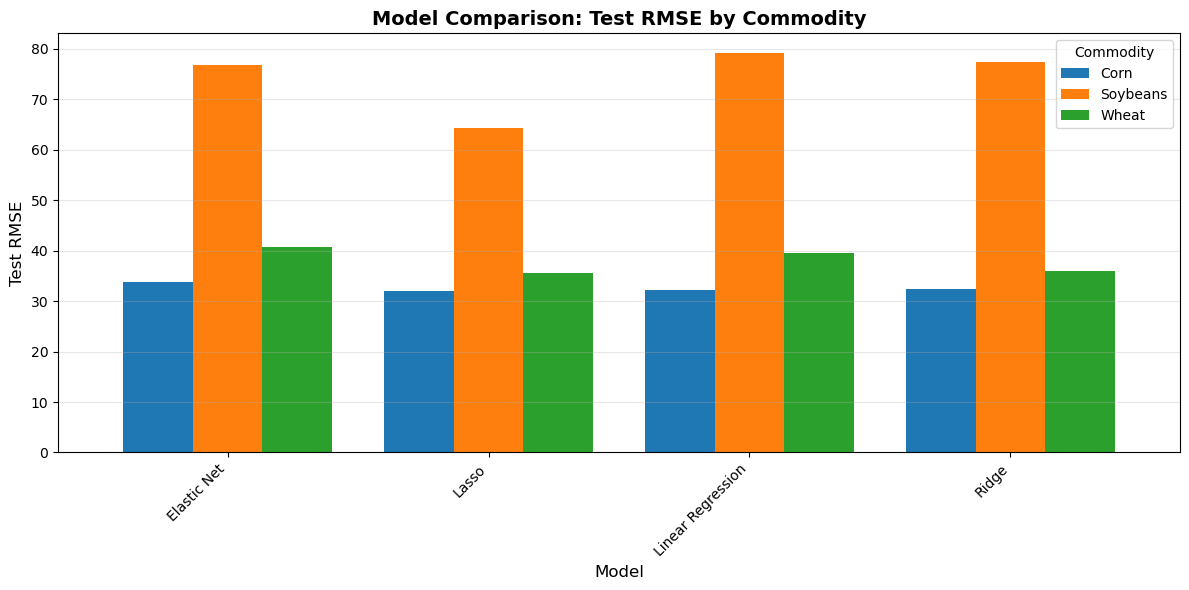

✓ Gráfico guardado: reports/figures/baseline_models_comparison.png


In [17]:
# Plot comparativo
fig, ax = plt.subplots(figsize=(12, 6))

comparison_pivot = comparison_df.pivot(index='Model', columns='Commodity', values='Test RMSE')
comparison_pivot.plot(kind='bar', ax=ax, width=0.8)

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Test RMSE', fontsize=12)
ax.set_title('Model Comparison: Test RMSE by Commodity', fontsize=14, fontweight='bold')
ax.legend(title='Commodity', fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig(BASE_DIR / 'reports' / 'figures' / 'baseline_models_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Gráfico guardado: reports/figures/baseline_models_comparison.png")

---

## 6. Guardar Modelos y Resultados

In [ ]:
import pickle

# Guardar modelos
models_dir = BASE_DIR / 'models'
models_dir.mkdir(exist_ok=True)

# Guardar todos los modelos en un diccionario
all_models = {
    'linear_regression': lr_models,
    'ridge': ridge_models,
    'lasso': lasso_models,
    'elastic_net': enet_models,
    'scaling_stats': scaling_stats,  # Guardar stats (mean/std) en lugar de scaler
    'feature_cols': feature_cols
}

models_file = models_dir / 'baseline_models.pkl'
with open(models_file, 'wb') as f:
    pickle.dump(all_models, f)

print(f"✓ Modelos guardados: {models_file}")

# Guardar resultados en JSON
results_summary = {
    'fecha_generacion': pd.Timestamp.now().isoformat(),
    'models': ['Linear Regression', 'Ridge', 'Lasso', 'Elastic Net'],
    'commodities': TARGET_COMMODITIES,
    'split_date': split_date,
    'results': comparison_df.to_dict(orient='records'),
    'best_models': {},
    'hyperparameters': {
        'ridge_alphas': ridge_best_alphas,
        'lasso_alphas': lasso_best_alphas,
        'enet_params': enet_best_params
    },
    'feature_selection': {
        'lasso': {c: len(feats) for c, feats in lasso_selected_features.items()}
    }
}

# Identificar mejor modelo por commodity
for commodity in TARGET_COMMODITIES:
    commodity_results = comparison_df[comparison_df['Commodity'] == commodity].sort_values('Test RMSE')
    results_summary['best_models'][commodity] = commodity_results.iloc[0]['Model']

results_file = PROCESSED_DIR / 'baseline_models_results.json'
with open(results_file, 'w') as f:
    json.dump(results_summary, f, indent=2)

print(f"✓ Resultados guardados: {results_file}")

NameError: name 'scaler' is not defined